<a href="https://colab.research.google.com/github/Edwinshajan2006/data-science-/blob/main/EDWIN_SHAJAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1: Dataset Selection


## Task 2: Problem Definition


## Task 3: Data Loading & Understanding


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

# Load the dataset
df = pd.read_csv("tips.csv")
df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
print("Dataset Shape:", df.shape)


Dataset Shape: (244, 7)


In [ ]:
print("Column Names:")
print(df.columns.tolist())


Column Names:
['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


In [ ]:
print("Data Types:")
print(df.dtypes)


Data Types:
total_bill    float64
tip           float64
sex               str
smoker            str
day               str
time              str
size            int64
dtype: object


In [ ]:
print("Missing Values per Column:")
print(df.isnull().sum())


Missing Values per Column:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


## Task 4: Data Cleaning


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Number of duplicate rows: 1
Shape after removing duplicates: (243, 7)


## Task 5: EDA


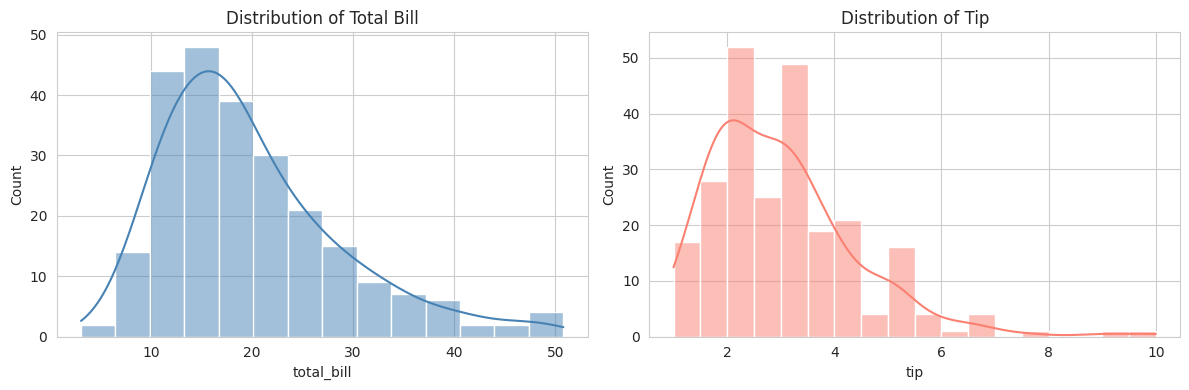

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['total_bill'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Total Bill')
sns.histplot(df['tip'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Tip')
plt.tight_layout()
plt.show()


Both total_bill and tip are kinda right-skewed — most people pay smaller bills/tips, but there's a few big spenders pulling the tail out to the right. Pretty normal for spending data tbh.

/tmp/ipykernel_602/1590057399.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='day', data=df, ax=axes[0], palette='viridis', order=['Thur','Fri','Sat','Sun'])
/tmp/ipykernel_602/1590057399.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='time', data=df, ax=axes[1], palette='magma')


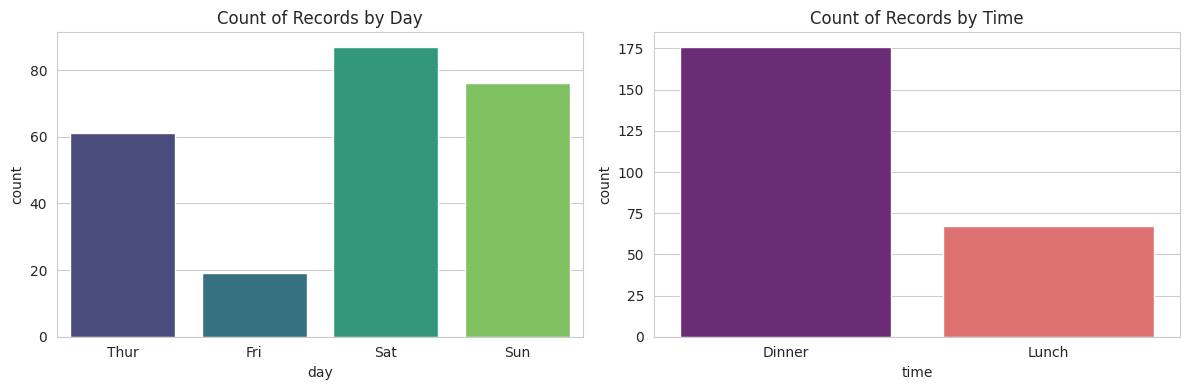

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='day', data=df, ax=axes[0], palette='viridis', order=['Thur','Fri','Sat','Sun'])
axes[0].set_title('Count of Records by Day')
sns.countplot(x='time', data=df, ax=axes[1], palette='magma')
axes[1].set_title('Count of Records by Time')
plt.tight_layout()
plt.show()


Sat and Sun clearly have way more entries than weekdays, so the place is busiest on weekends. Also dinner has more records than lunch, so evenings are when most people show up.

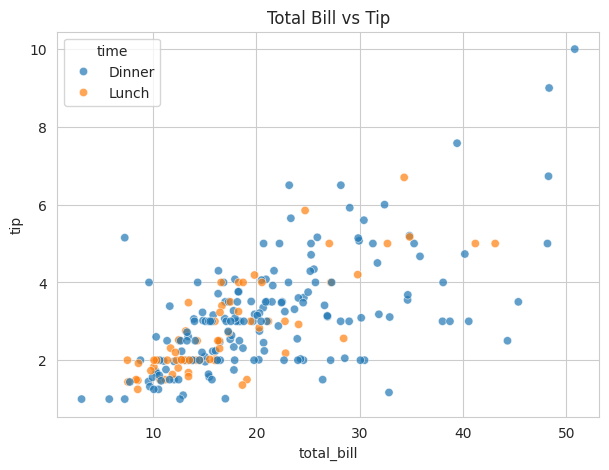

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='total_bill', y='tip', data=df, hue='time', alpha=0.7)
plt.title('Total Bill vs Tip')
plt.show()


You can see a pretty obvious trend here — bigger bill, bigger tip. Makes sense, and it means total_bill is probably gonna be the strongest feature for the model.

/tmp/ipykernel_602/3352898048.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day', y='tip', data=df, ax=axes[0], order=['Thur','Fri','Sat','Sun'], palette='Set2')
/tmp/ipykernel_602/3352898048.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex', y='tip', data=df, ax=axes[1], palette='Set3')


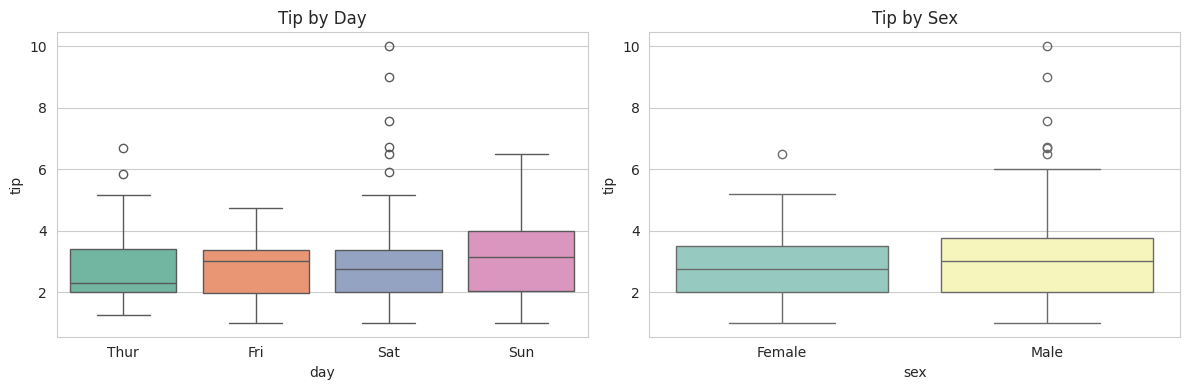

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='day', y='tip', data=df, ax=axes[0], order=['Thur','Fri','Sat','Sun'], palette='Set2')
axes[0].set_title('Tip by Day')
sns.boxplot(x='sex', y='tip', data=df, ax=axes[1], palette='Set3')
axes[1].set_title('Tip by Sex')
plt.tight_layout()
plt.show()


Tips on Sat/Sun look a bit higher and more spread out compared to weekdays. Not much difference between male/female tippers, maybe guys have a couple more high outliers but nothing major.

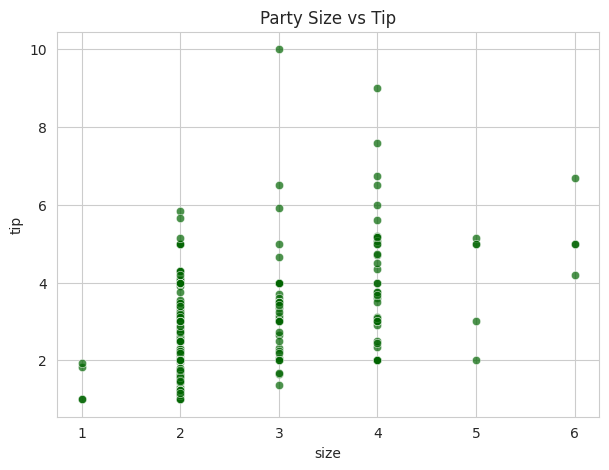

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='size', y='tip', data=df, alpha=0.7, color='darkgreen')
plt.title('Party Size vs Tip')
plt.show()


Bigger groups tend to tip more on average, which checks out since bigger groups = bigger bills usually.

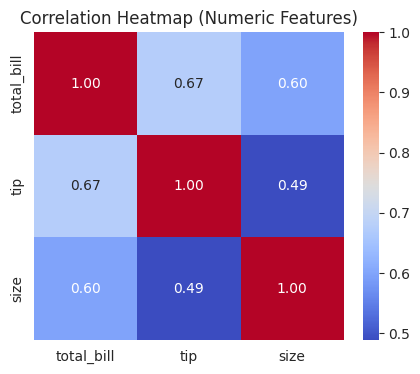

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()


total_bill has the strongest correlation with tip (around 0.68), so that's our main predictor. size is also somewhat correlated (~0.49), so it'll probably help too.

## Task 6: Data Preprocessing


In [ ]:
X = df.drop('tip', axis=1)
y = df['tip']

categorical_features = ['sex', 'smoker', 'day', 'time']
numeric_features = ['total_bill', 'size']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (194, 6)
Testing set shape: (49, 6)


## Task 7: Model Building


In [ ]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)
print("Model training complete.")


Model training complete.


In [ ]:
# Inspect model coefficients
feature_names = numeric_features + list(
    model.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)
coefficients = model.named_steps['regressor'].coef_
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df


,Feature,Coefficient
0,total_bill,0.085483
1,size,0.210989
2,sex_Male,0.018162
3,smoker_Yes,-0.052130
4,day_Sat,0.103283
5,day_Sun,0.167782
6,day_Thur,-0.049832
7,time_Lunch,0.194669


## Task 8: Model Evaluation


In [ ]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R\u00b2 Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


R² Score: 0.5186
Mean Absolute Error (MAE): 0.7665
Root Mean Squared Error (RMSE): 1.0831


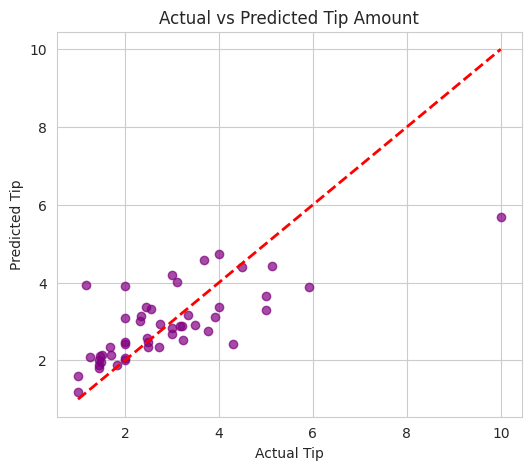

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.7, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Tip')
plt.ylabel('Predicted Tip')
plt.title('Actual vs Predicted Tip Amount')
plt.show()


## Task 9: Result Interpretation


## Task 10: Final Conclusion
